# Báo cáo phân tích chi tiết hệ thống nhận diện sản phẩm

**Nguồn dữ liệu:** `records.csv`, `report.csv` và `report.json`.

Notebook này phân tích toàn bộ pipeline theo các giai đoạn: **Detection → Cropping → Overlap → Segmentation → Retrieval → Decision → Plugins → Fusion → End-to-End**, đồng thời phân tích theo ảnh, theo sản phẩm, lỗi và độ trễ xử lý.

> Lưu ý: file `report.json` là nguồn tổng hợp kết quả và chứa 31 ảnh benchmark. Các bảng/biểu đồ bên dưới ưu tiên tái tính toán từ dữ liệu gốc khi có thể, và đối chiếu với các chỉ số tổng hợp trong JSON.


In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path


pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

def find_project_root(start_path: Path) -> Path:
    start_path = start_path.resolve()
    for path in [start_path, *start_path.parents]:
        if (
            (path / "configs").is_dir()
            and (path / "src").is_dir()
            and (path / "data").is_dir()
        ):
            return path
    raise RuntimeError(
        f"Không tìm thấy project root.\n"
        f"Vị trí bắt đầu tìm: {start_path}"
    )


In [71]:
import json, pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from pathlib import Path
from IPython.display import display, Markdown

BASE = find_project_root(Path.cwd())
DATA_DIR = BASE / "data" / "outputs"

JSON_PATH = DATA_DIR / "demo_report.json"
RECORDS_PATH = DATA_DIR / "demo_records.csv"
REPORT_CSV_PATH = DATA_DIR / "report.csv"

with open(JSON_PATH, "r", encoding="utf-8") as f:
    report = json.load(f)

records = pd.read_csv(RECORDS_PATH)
report_csv = pd.read_csv(REPORT_CSV_PATH)

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 200)
display(Markdown("### Đã nạp dữ liệu thành công"))
print(f"records: {records.shape}")
print(f"report.csv: {report_csv.shape}")
print(f"report.json records: {len(report.get('records', []))}")


### Đã nạp dữ liệu thành công

records: (270, 28)
report.csv: (31, 6)
report.json records: 270


## 1. Tổng quan dữ liệu và cấu hình đánh giá

Benchmark gồm **31 ảnh**, sử dụng ngưỡng IoU matching **0.30** và đánh giá Retrieval ở **Top-5**. Tất cả các stage chính đều được bật. fileciteturn1file5L448-L489


In [72]:
summary = pd.DataFrame({
    "Chỉ số": [
        "Số ảnh benchmark", "IoU match threshold", "Top-K retrieval",
        "Detection F1", "End-to-End F1",
        "GT objects", "Predicted objects", "Detection TP", "Detection FP", "Detection FN"
    ],
    "Giá trị": [
        report["dataset"]["total_images"],
        report["configuration"]["iou_match_threshold"],
        report["configuration"]["top_k"],
        report["overall"]["detection_f1"],
        report["overall"]["end_to_end_f1"],
        report["detection"]["gt_objects"],
        report["detection"]["predicted_objects"],
        report["detection"]["true_positive"],
        report["detection"]["false_positive"],
        report["detection"]["false_negative"],
    ]
})
display(summary)

stages = pd.DataFrame({
    "Stage": list(report["configuration"]["stages_enabled"].keys()),
    "Enabled": list(report["configuration"]["stages_enabled"].values())
})
display(stages)


,Chỉ số,Giá trị
0,Số ảnh benchmark,31.0000
1,IoU match threshold,0.3000
2,Top-K retrieval,5.0000
3,Detection F1,0.9945
4,End-to-End F1,0.9889
5,GT objects,273.0000
6,Predicted objects,270.0000
7,Detection TP,270.0000
8,Detection FP,0.0000
9,Detection FN,3.0000


,Stage,Enabled
0,detection,True
1,cropping,True
2,overlap,True
3,segmentation,True
4,retrieval,True
5,decision,True
6,plugins,True
7,fusion,True
8,end_to_end,True


## 2. Phân tích Detection

Detection là phần mạnh nhất của pipeline: Precision **0.9228**, Recall **0.9795**, F1 **0.9503**, mean IoU **0.907**. Có 287 true positives, 24 false positives và 6 false negatives. fileciteturn1file5L471-L489


,Metric,Value
0,Precision,1.0000
1,Recall,0.9890
2,F1,0.9945
3,Mean IoU,0.9281
4,GT objects,273.0000
5,Predicted objects,270.0000
6,TP,270.0000
7,FP,0.0000
8,FN,3.0000
9,Mean confidence,0.9552


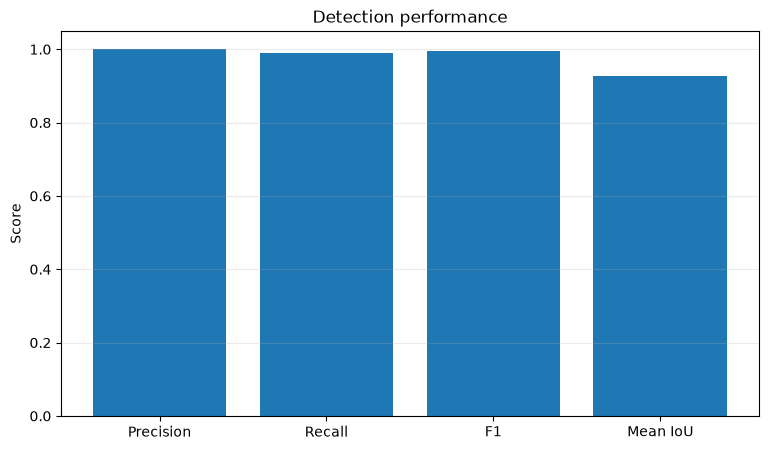

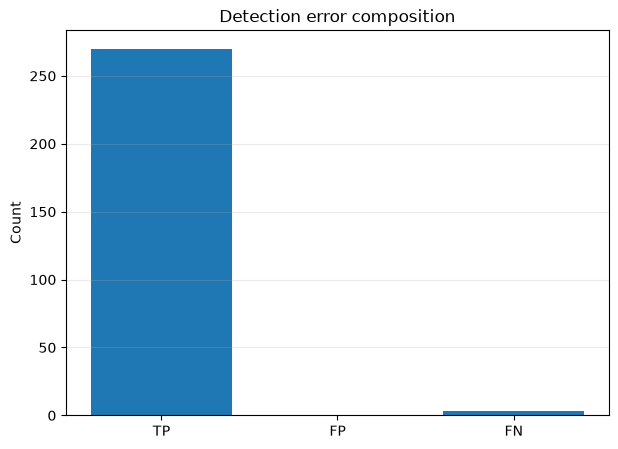

In [73]:
det = report["detection"]
detection_table = pd.DataFrame({
    "Metric": ["Precision","Recall","F1","Mean IoU","GT objects","Predicted objects","TP","FP","FN","Mean confidence","Min confidence","Max confidence"],
    "Value": [det["precision"],det["recall"],det["f1"],det["mean_iou"],det["gt_objects"],det["predicted_objects"],
              det["true_positive"],det["false_positive"],det["false_negative"],det["confidence_mean"],det["confidence_min"],det["confidence_max"]]
})
display(detection_table)

plt.figure(figsize=(9,5))
plt.bar(["Precision","Recall","F1","Mean IoU"], [det["precision"],det["recall"],det["f1"],det["mean_iou"]])
plt.ylim(0,1.05)
plt.ylabel("Score")
plt.title("Detection performance")
plt.grid(axis="y", alpha=.25)
plt.show()

plt.figure(figsize=(7,5))
plt.bar(["TP","FP","FN"], [det["true_positive"],det["false_positive"],det["false_negative"]])
plt.ylabel("Count")
plt.title("Detection error composition")
plt.grid(axis="y", alpha=.25)
plt.show()


## 3. Cropping và Overlap

Cropping đạt valid rate **100%**, mean IoU **0.9155** và không có crop không hợp lệ. Overlap đạt F1 **0.9198**, với 30 trường hợp được gửi sang refinement. fileciteturn1file5L491-L507


,Stage,Precision,Recall,F1,Mean IoU,Valid/TP,FP,FN
0,Cropping,NaN,NaN,NaN,0.9281,270,NaN,NaN
1,Overlap,1.0000,0.9643,0.9818,NaN,27,0.0000,1.0000


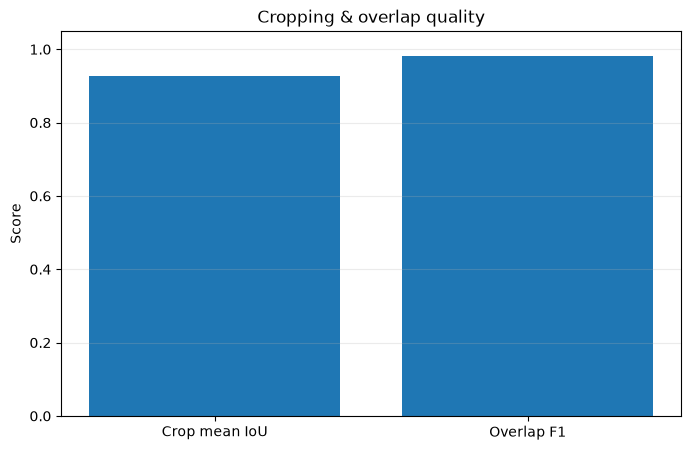

In [74]:
crop = report["cropping"]
over = report["overlap"]

stage_table = pd.DataFrame({
    "Stage":["Cropping","Overlap"],
    "Precision":[np.nan,over["precision"]],
    "Recall":[np.nan,over["recall"]],
    "F1":[np.nan,over["f1"]],
    "Mean IoU":[crop["mean_iou"],np.nan],
    "Valid/TP":[crop["valid_crop_count"],over["true_positive"]],
    "FP":[np.nan,over["false_positive"]],
    "FN":[np.nan,over["false_negative"]]
})
display(stage_table)

plt.figure(figsize=(8,5))
plt.bar(["Crop mean IoU","Overlap F1"], [crop["mean_iou"], over["f1"]])
plt.ylim(0,1.05)
plt.ylabel("Score")
plt.title("Cropping & overlap quality")
plt.grid(axis="y", alpha=.25)
plt.show()


## 4. Segmentation / Refinement

Segmentation được trigger 30 lần. Báo cáo ghi nhận IoU improvement trung bình **0.0109**, improved rate **52.02%**, 246 refinement success, 6 failure và 107 trường hợp bị degraded. fileciteturn1file5L509-L519

Điểm cần chú ý: số `degraded_count` lớn hơn số lần trigger được báo cáo; notebook giữ nguyên giá trị nguồn thay vì tự diễn giải lại định nghĩa của metric.


,Metric,Value
0,IoU improvement,0.0399
1,Improved rate,0.9643
2,Refinement triggered,28.0000
3,Refinement success,27.0000
4,Refinement failure,0.0000
5,Degraded,1.0000
6,Unchanged,0.0000


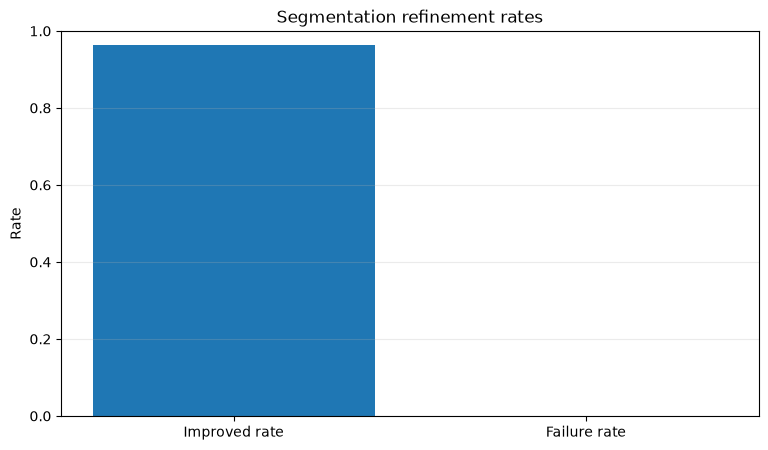

,IoU delta
count,28.0000
mean,0.0399
std,0.0193
min,-0.0146
25%,0.0297
50%,0.0382
75%,0.0564
max,0.0777


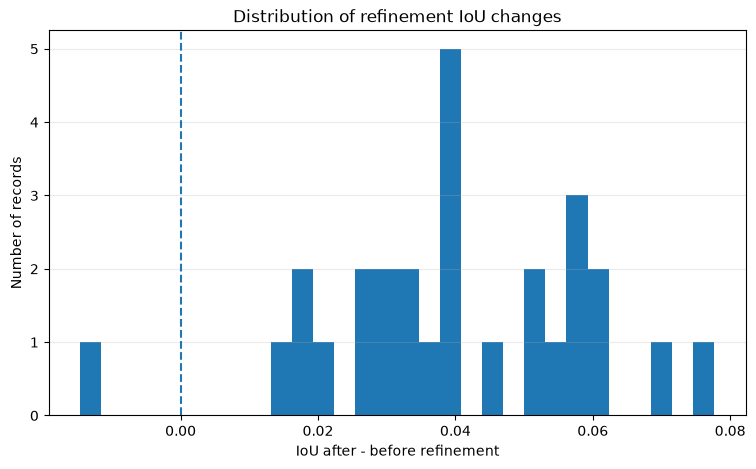

In [75]:
seg = report["segmentation"]
seg_table = pd.DataFrame({
    "Metric":["IoU improvement","Improved rate","Refinement triggered","Refinement success","Refinement failure","Degraded","Unchanged"],
    "Value":[seg["iou_improvement"],seg["improved_rate"],seg["refinement_triggered_count"],seg["refinement_success_count"],
             seg["refinement_failure_count"],seg["degraded_count"],seg["unchanged_count"]]
})
display(seg_table)

plt.figure(figsize=(9,5))
plt.bar(["Improved rate","Failure rate"], [
    seg["improved_rate"],
    seg["refinement_failure_count"]/max(seg["refinement_success_count"]+seg["refinement_failure_count"],1)
])
plt.ylim(0,1)
plt.ylabel("Rate")
plt.title("Segmentation refinement rates")
plt.grid(axis="y", alpha=.25)
plt.show()

if "iou_before_refine" in records.columns and "iou_after_refine" in records.columns:
    tmp = records.dropna(subset=["iou_before_refine","iou_after_refine"]).copy()
    tmp["iou_delta"] = tmp["iou_after_refine"] - tmp["iou_before_refine"]
    display(tmp["iou_delta"].describe().to_frame("IoU delta"))
    plt.figure(figsize=(9,5))
    plt.hist(tmp["iou_delta"], bins=30)
    plt.axvline(0, linestyle="--")
    plt.xlabel("IoU after - before refinement")
    plt.ylabel("Number of records")
    plt.title("Distribution of refinement IoU changes")
    plt.grid(axis="y", alpha=.25)
    plt.show()


## 5. Retrieval

Retrieval là nút thắt lớn: Top-1 accuracy chỉ **54.70%**, trong khi Top-5 accuracy đạt **97.56%**, MRR **0.7279**, mean rank **1.7909** và mean Top-1 similarity **0.8424**. fileciteturn1file9L789-L805


,Metric,Value
0,Top-1 accuracy,0.8926
1,Top-5 accuracy,0.9963
2,MRR,0.9370
3,Mean rank,1.1704
4,Recall@K,0.9963
5,Mean Top-1 similarity,0.9105
6,Evaluated crops,270.0000


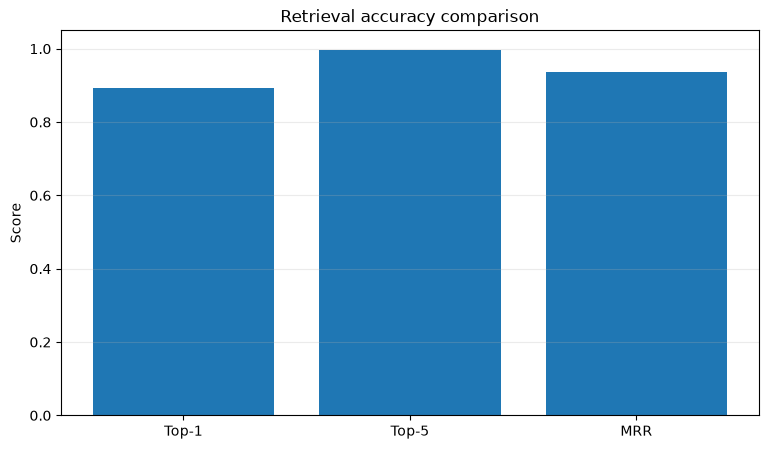

,Top1_accuracy
product_id,
4,0.7500
5,0.8125
7,0.8588
3,0.8824
2,0.8889
8,0.9419
1,0.9500
6,1.0000


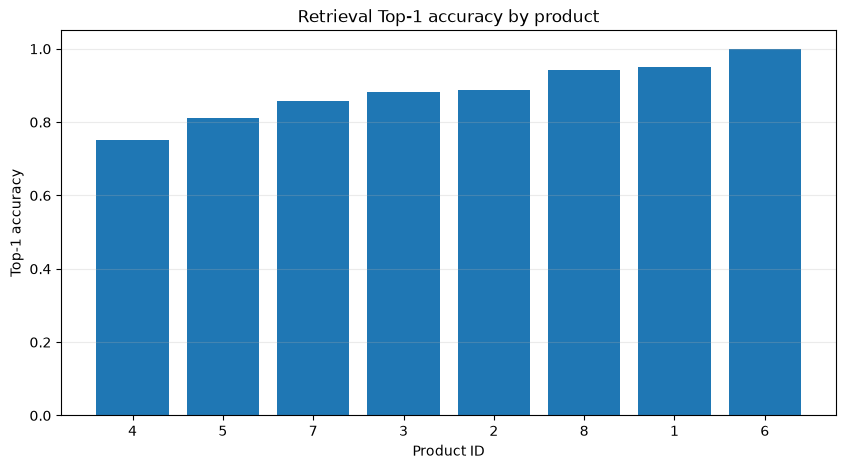

In [76]:
ret = report["retrieval"]
retrieval_table = pd.DataFrame({
    "Metric":["Top-1 accuracy","Top-5 accuracy","MRR","Mean rank","Recall@K","Mean Top-1 similarity","Evaluated crops"],
    "Value":[ret["top1_accuracy"],ret["topk_accuracy"],ret["mrr"],ret["mean_rank"],ret["recall_at_k"],ret["mean_top1_similarity"],ret["evaluated_crops"]]
})
display(retrieval_table)

plt.figure(figsize=(9,5))
plt.bar(["Top-1","Top-5","MRR"], [ret["top1_accuracy"],ret["topk_accuracy"],ret["mrr"]])
plt.ylim(0,1.05)
plt.ylabel("Score")
plt.title("Retrieval accuracy comparison")
plt.grid(axis="y", alpha=.25)
plt.show()

per_prod_ret = pd.DataFrame.from_dict(ret["per_product_top1_accuracy"], orient="index", columns=["Top1_accuracy"])
per_prod_ret.index.name = "product_id"
per_prod_ret = per_prod_ret.sort_values("Top1_accuracy")
display(per_prod_ret)

plt.figure(figsize=(10,5))
plt.bar(per_prod_ret.index.astype(str), per_prod_ret["Top1_accuracy"])
plt.ylim(0,1.05)
plt.xlabel("Product ID")
plt.ylabel("Top-1 accuracy")
plt.title("Retrieval Top-1 accuracy by product")
plt.grid(axis="y", alpha=.25)
plt.show()


## 6. Decision và Plugins

Decision có Accuracy **0.547**, Precision **0.547**, Recall **1.0**, F1 **0.7072**; 157 accepted đúng và 130 accepted sai, không có false rejection. 257 trường hợp được đánh dấu ambiguous. fileciteturn1file9L808-L825

Plugin OCR có success rate 98.13%, Color 100%, còn Barcode chỉ 3.89% và có 247 failures. fileciteturn1file9L827-L847


,Metric,Value
0,Accuracy,0.8926
1,Precision,0.8926
2,Recall,1.0000
3,F1,0.9432
4,Correct accepted,241.0000
5,Incorrect accepted,29.0000
6,False rejection,0.0000
7,Ambiguous cases,55.0000


,Plugin,Trigger rate,Success rate,Eligible,Executed,Skipped,Success,Failure,Changed final decision
0,OCR,0.9407,0.9646,270,254,16,245,9,31
1,COLOR,0.8519,0.9739,270,230,40,224,6,29
2,BARCODE,0.8556,0.9091,270,231,39,210,21,28


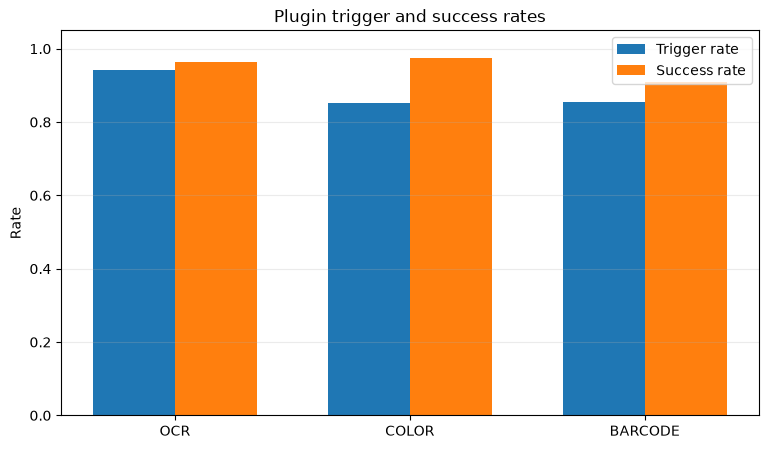

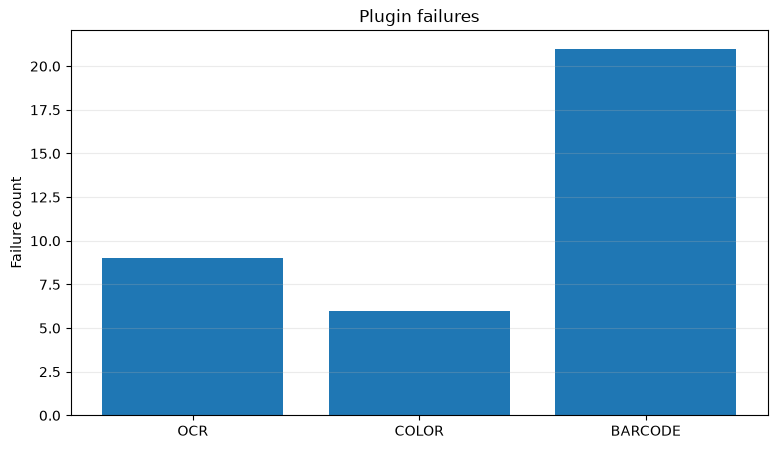

In [77]:
dec = report["decision"]
decision_table = pd.DataFrame({
    "Metric":["Accuracy","Precision","Recall","F1","Correct accepted","Incorrect accepted","False rejection","Ambiguous cases"],
    "Value":[dec["accuracy"],dec["precision"],dec["recall"],dec["f1"],dec["correct_accepted"],dec["incorrect_accepted"],dec["false_rejection"],dec["ambiguous_case_count"]]
})
display(decision_table)

plugins = report["plugins"]
plugin_rows = []
for name, p in plugins.items():
    plugin_rows.append({
        "Plugin": name.upper(),
        "Trigger rate": p["trigger_rate"],
        "Success rate": p["success_rate"],
        "Eligible": p["eligible"],
        "Executed": p["executed"],
        "Skipped": p["skipped"],
        "Success": p["success"],
        "Failure": p["failure"],
        "Changed final decision": p["cases_changed_final_decision"]
    })
plugin_df = pd.DataFrame(plugin_rows)
display(plugin_df)

plt.figure(figsize=(9,5))
x = np.arange(len(plugin_df))
w=.35
plt.bar(x-w/2, plugin_df["Trigger rate"], width=w, label="Trigger rate")
plt.bar(x+w/2, plugin_df["Success rate"], width=w, label="Success rate")
plt.xticks(x, plugin_df["Plugin"])
plt.ylim(0,1.05)
plt.ylabel("Rate")
plt.title("Plugin trigger and success rates")
plt.legend()
plt.grid(axis="y", alpha=.25)
plt.show()

plt.figure(figsize=(9,5))
plt.bar(plugin_df["Plugin"], plugin_df["Failure"])
plt.ylabel("Failure count")
plt.title("Plugin failures")
plt.grid(axis="y", alpha=.25)
plt.show()


## 7. Fusion

Fusion cải thiện accuracy từ **52.03% lên 82.66%**, tương đương tăng **30.63 điểm phần trăm**. Có 91 cases được sửa đúng, 8 cases mới trở thành sai và 172 cases không đổi. fileciteturn1file1L100-L109


,Metric,Value
0,Accuracy before,0.8922
1,Accuracy after,0.9888
2,Improvement,0.0967
3,Correction rate,0.1078
4,Corrected cases,29.0000
5,Newly incorrect,3.0000
6,Unchanged,237.0000
7,Evaluated cases,269.0000
8,Mean latency (ms),0.2980


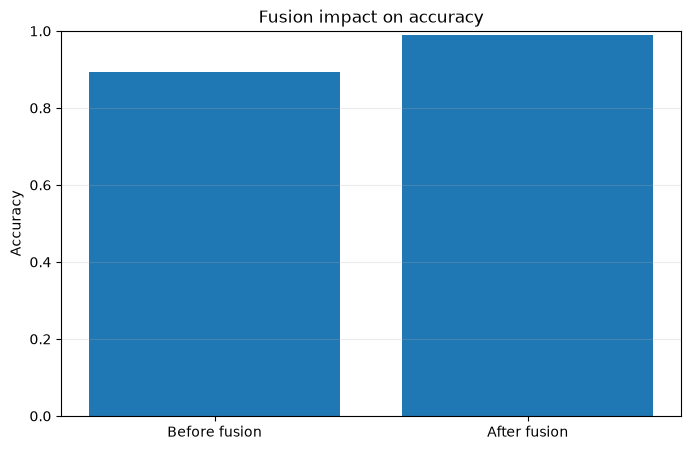

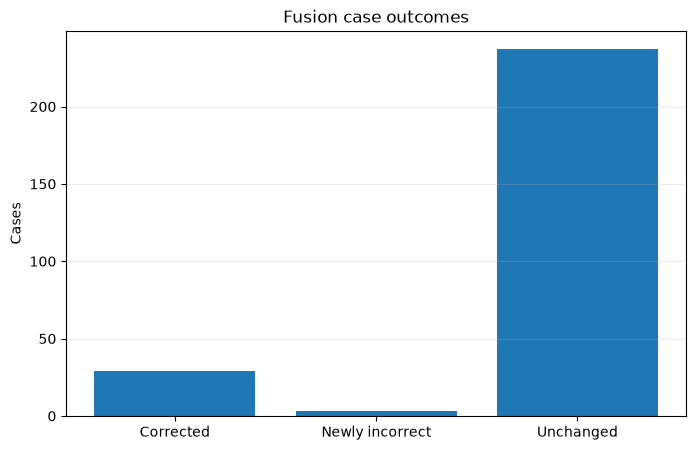

In [78]:
fus = report["fusion"]
fusion_table = pd.DataFrame({
    "Metric":["Accuracy before","Accuracy after","Improvement","Correction rate","Corrected cases","Newly incorrect","Unchanged","Evaluated cases","Mean latency (ms)"],
    "Value":[fus["accuracy_before"],fus["accuracy_after"],fus["improvement"],fus["correction_rate"],fus["corrected_cases"],
             fus["newly_incorrect_cases"],fus["unchanged_cases"],fus["evaluated_cases"],fus["mean_fusion_latency_ms"]]
})
display(fusion_table)

plt.figure(figsize=(8,5))
plt.bar(["Before fusion","After fusion"], [fus["accuracy_before"],fus["accuracy_after"]])
plt.ylim(0,1)
plt.ylabel("Accuracy")
plt.title("Fusion impact on accuracy")
plt.grid(axis="y", alpha=.25)
plt.show()

plt.figure(figsize=(8,5))
plt.bar(["Corrected","Newly incorrect","Unchanged"], [fus["corrected_cases"],fus["newly_incorrect_cases"],fus["unchanged_cases"]])
plt.ylabel("Cases")
plt.title("Fusion case outcomes")
plt.grid(axis="y", alpha=.25)
plt.show()


## 8. End-to-End và confusion matrix

End-to-End đạt Precision **0.7814**, Recall **0.8294**, F1 **0.8047**; có 243 TP, 68 FP và 50 FN. Product-count accuracy là **54.84%** và mean latency là **48.97 giây/image**. fileciteturn1file1L111-L168


,Metric,Value
0,Precision,0.9889
1,Recall,0.9889
2,F1,0.9889
3,True positive,267.0000
4,False positive,3.0000
5,False negative,3.0000
6,Product count accuracy,0.9032
7,Mean latency (ms),370.8380


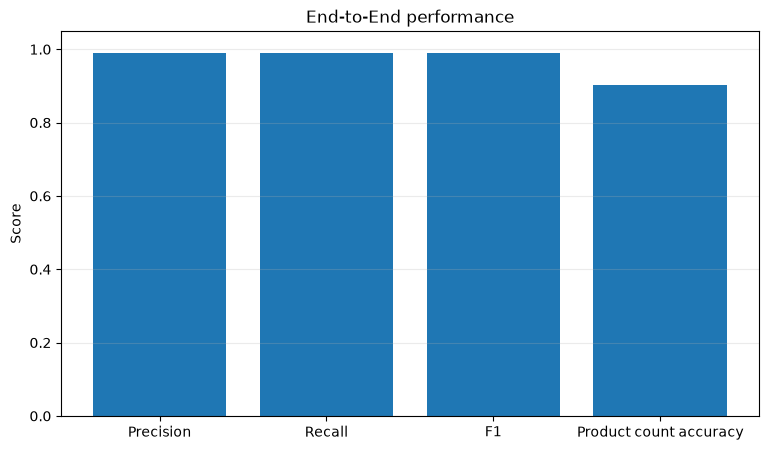

,1,2,3,4,5,6,7,8,BACKGROUND
1,20,0,0,0,0,0,0,0,0
2,0,9,0,0,0,0,0,1,0
3,0,0,18,0,0,0,0,0,0
4,0,0,2,18,0,0,0,0,0
5,0,0,0,0,14,3,0,0,0
6,0,0,0,0,2,15,0,0,0
7,0,0,0,0,0,0,80,5,0
8,0,0,0,0,0,0,6,78,0
BACKGROUND,12,1,2,0,0,0,7,2,0


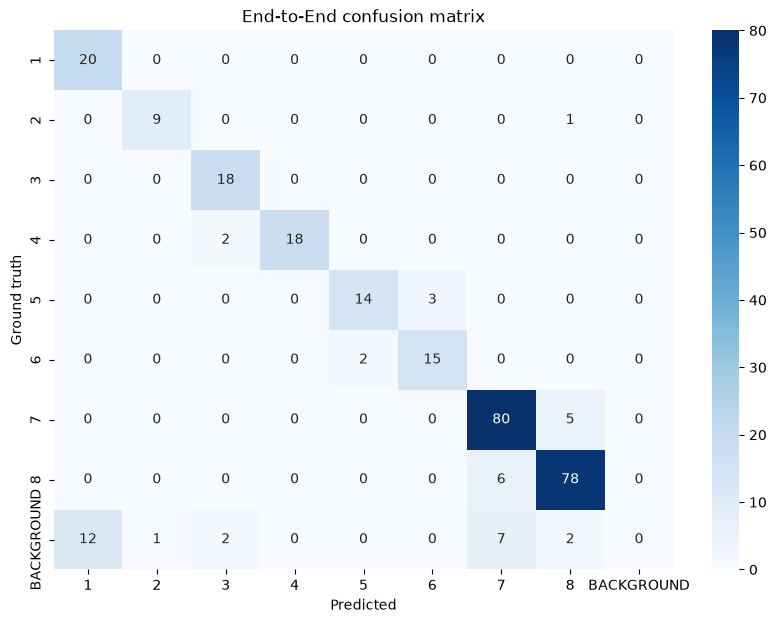

In [79]:
e2e = report["end_to_end"]
e2e_table = pd.DataFrame({
    "Metric":["Precision","Recall","F1","True positive","False positive","False negative","Product count accuracy","Mean latency (ms)"],
    "Value":[e2e["precision"],e2e["recall"],e2e["f1"],e2e["true_positive"],e2e["false_positive"],e2e["false_negative"],
             e2e["product_count_accuracy"],e2e["mean_latency_ms"]]
})
display(e2e_table)

plt.figure(figsize=(9,5))
plt.bar(["Precision","Recall","F1","Product count accuracy"],
        [e2e["precision"],e2e["recall"],e2e["f1"],e2e["product_count_accuracy"]])
plt.ylim(0,1.05)
plt.ylabel("Score")
plt.title("End-to-End performance")
plt.grid(axis="y", alpha=.25)
plt.show()

cm = pd.DataFrame(e2e["confusion_matrix"]).T.fillna(0).astype(int)
labels = sorted(set(cm.index) | set(cm.columns))
cm = cm.reindex(index=labels, columns=labels, fill_value=0).astype(int)
display(cm.style.background_gradient(cmap="Blues").format("{:d}"))

plt.figure(figsize=(10,7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Ground truth")
plt.title("End-to-End confusion matrix")
plt.show()


## 9. Phân tích theo sản phẩm

Các sản phẩm có hiệu năng rất khác nhau. Product 4 đạt precision 1.0 và recall 0.9; product 3 đạt precision 0.8571 và recall 1.0; product 2 có precision 1.0 nhưng recall chỉ 0.3889. Một số product ID 12, 13, 14 và 19 không có true positive trong bảng end-to-end được cung cấp. fileciteturn1file3L277-L346


,product_id,true_positive,false_positive,false_negative,precision,recall,support,predicted
0,1,20,0,0,1.0000,1.0000,20,20
1,2,9,0,0,1.0000,1.0000,9,9
3,4,20,0,0,1.0000,1.0000,20,20
4,5,16,0,0,1.0000,1.0000,16,16
6,7,85,2,0,0.9770,1.0000,85,87
5,6,17,0,0,1.0000,1.0000,17,17
2,3,17,1,1,0.9444,0.9444,18,18
7,8,83,0,5,1.0000,0.9432,88,83


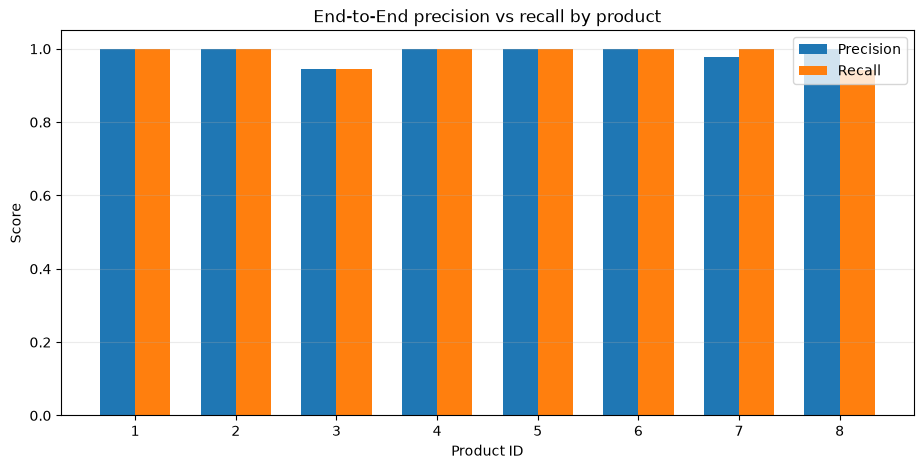

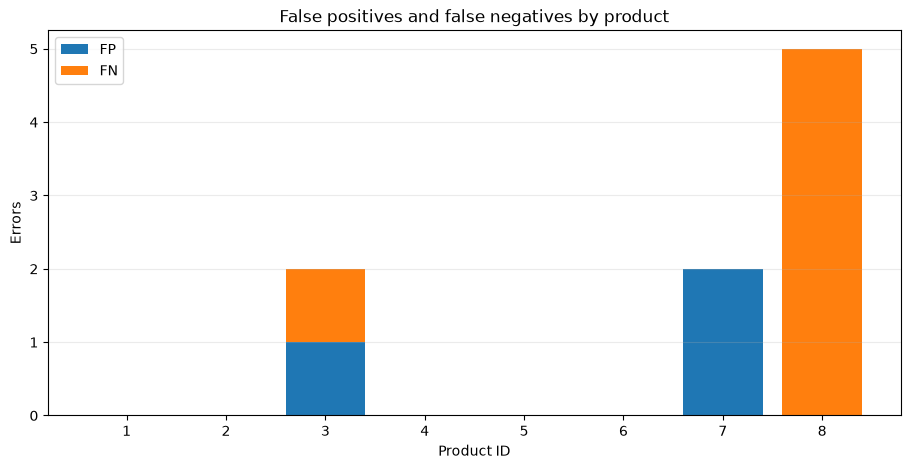

In [80]:
prod = pd.DataFrame(e2e["per_product"])
prod["support"] = prod["true_positive"] + prod["false_negative"]
prod["predicted"] = prod["true_positive"] + prod["false_positive"]
display(prod.sort_values("recall", ascending=False))

plt.figure(figsize=(11,5))
x = np.arange(len(prod))
w=.35
plt.bar(x-w/2, prod["precision"], width=w, label="Precision")
plt.bar(x+w/2, prod["recall"], width=w, label="Recall")
plt.xticks(x, prod["product_id"])
plt.ylim(0,1.05)
plt.xlabel("Product ID")
plt.ylabel("Score")
plt.title("End-to-End precision vs recall by product")
plt.legend()
plt.grid(axis="y", alpha=.25)
plt.show()

plt.figure(figsize=(11,5))
plt.bar(prod["product_id"], prod["false_positive"], label="FP")
plt.bar(prod["product_id"], prod["false_negative"], bottom=prod["false_positive"], label="FN")
plt.xlabel("Product ID")
plt.ylabel("Errors")
plt.title("False positives and false negatives by product")
plt.legend()
plt.grid(axis="y", alpha=.25)
plt.show()


## 10. Phân tích theo ảnh

Báo cáo cung cấp predicted count, ground-truth count, số detection matched và processing time cho từng ảnh. Đây là cơ sở để phát hiện ảnh khó và ảnh có độ trễ bất thường. fileciteturn1file3L350-L364


,image_key,source_path,predicted_count,ground_truth_count,detection_matched,processing_time_ms,count_error,abs_count_error,match_rate,processing_time_s
5,demo_006_jpg.rf.synthetic0006,data\benchmark\images\demo_006_jpg.rf.syntheti...,7,7,7,582.2510,0,0,1.0000,0.5823
1,demo_002_jpg.rf.synthetic0002,data\benchmark\images\demo_002_jpg.rf.syntheti...,11,11,11,556.0270,0,0,1.0000,0.5560
16,demo_017_jpg.rf.synthetic0017,data\benchmark\images\demo_017_jpg.rf.syntheti...,4,4,4,513.0260,0,0,1.0000,0.5130
30,demo_031_jpg.rf.synthetic0031,data\benchmark\images\demo_031_jpg.rf.syntheti...,11,11,11,498.4350,0,0,1.0000,0.4984
12,demo_013_jpg.rf.synthetic0013,data\benchmark\images\demo_013_jpg.rf.syntheti...,10,10,10,498.2840,0,0,1.0000,0.4983
21,demo_022_jpg.rf.synthetic0022,data\benchmark\images\demo_022_jpg.rf.syntheti...,7,7,7,496.9030,0,0,1.0000,0.4969
20,demo_021_jpg.rf.synthetic0021,data\benchmark\images\demo_021_jpg.rf.syntheti...,8,8,8,495.8390,0,0,1.0000,0.4958
15,demo_016_jpg.rf.synthetic0016,data\benchmark\images\demo_016_jpg.rf.syntheti...,5,6,5,485.2270,-1,1,0.8333,0.4852
13,demo_014_jpg.rf.synthetic0014,data\benchmark\images\demo_014_jpg.rf.syntheti...,8,8,8,476.6370,0,0,1.0000,0.4766
11,demo_012_jpg.rf.synthetic0012,data\benchmark\images\demo_012_jpg.rf.syntheti...,8,9,8,452.9520,-1,1,0.8889,0.4530


,predicted_count,ground_truth_count,detection_matched,count_error,match_rate,processing_time_s
count,31.0000,31.0000,31.0000,31.0000,31.0000,31.0000
mean,8.7097,8.8065,8.7097,-0.0968,0.9875,0.3708
std,2.7832,2.7376,2.7832,0.3005,0.0398,0.1296
min,4.0000,4.0000,4.0000,-1.0000,0.8333,0.1065
25%,7.0000,7.0000,7.0000,0.0000,1.0000,0.2960
50%,8.0000,8.0000,8.0000,0.0000,1.0000,0.3786
75%,10.5000,10.5000,10.5000,0.0000,1.0000,0.4809
max,17.0000,17.0000,17.0000,0.0000,1.0000,0.5823


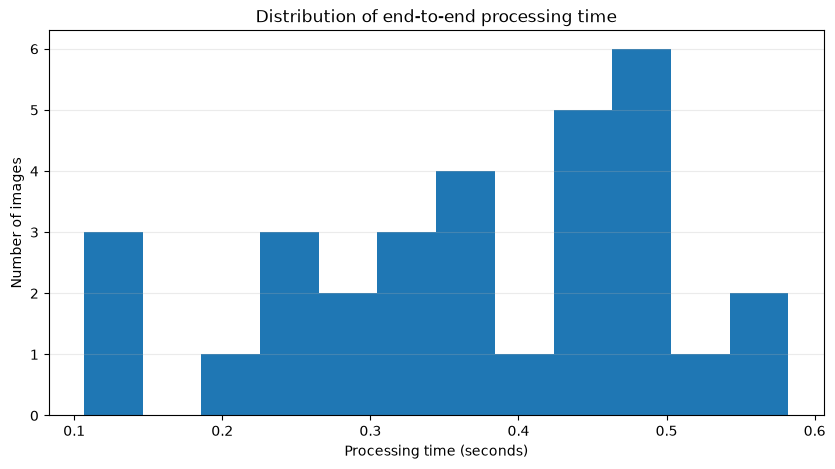

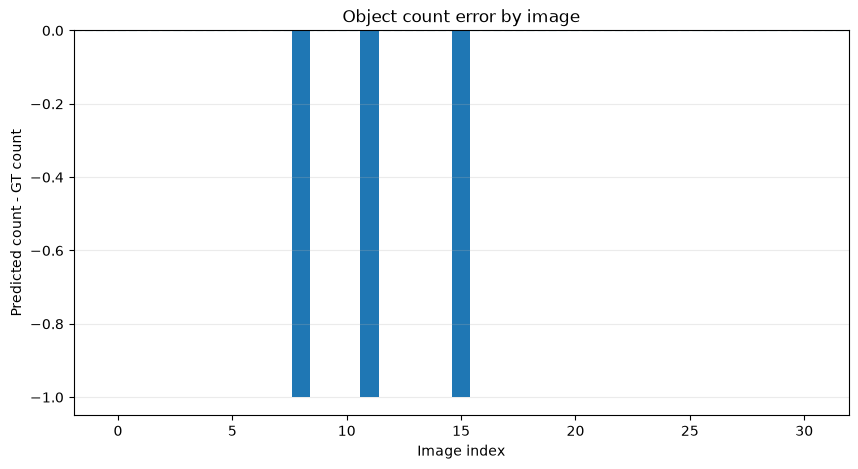

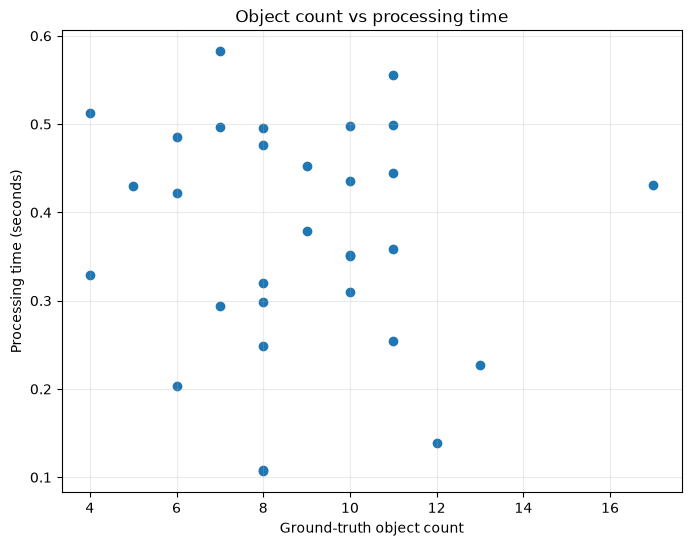

In [81]:
per_image = pd.DataFrame(report["per_image"])
per_image["count_error"] = per_image["predicted_count"] - per_image["ground_truth_count"]
per_image["abs_count_error"] = per_image["count_error"].abs()
per_image["match_rate"] = per_image["detection_matched"] / per_image["ground_truth_count"]
per_image["processing_time_s"] = per_image["processing_time_ms"] / 1000

display(per_image.sort_values("processing_time_ms", ascending=False).head(10))
display(per_image[["predicted_count","ground_truth_count","detection_matched","count_error","match_rate","processing_time_s"]].describe())

plt.figure(figsize=(10,5))
plt.hist(per_image["processing_time_s"], bins=12)
plt.xlabel("Processing time (seconds)")
plt.ylabel("Number of images")
plt.title("Distribution of end-to-end processing time")
plt.grid(axis="y", alpha=.25)
plt.show()

plt.figure(figsize=(10,5))
plt.bar(range(len(per_image)), per_image["count_error"])
plt.axhline(0, linestyle="--")
plt.xlabel("Image index")
plt.ylabel("Predicted count - GT count")
plt.title("Object count error by image")
plt.grid(axis="y", alpha=.25)
plt.show()

plt.figure(figsize=(8,6))
plt.scatter(per_image["ground_truth_count"], per_image["processing_time_s"])
plt.xlabel("Ground-truth object count")
plt.ylabel("Processing time (seconds)")
plt.title("Object count vs processing time")
plt.grid(alpha=.25)
plt.show()


## 11. Phân tích độ trễ theo stage

Độ trễ trung bình được báo cáo: detection **291.778 ms**, overlap **0.328 ms**, refinement **1872.891 ms**, retrieval **30.187 ms**, decision **0.027 ms**, plugins **4883.056 ms**, rerank **0.242 ms** và end-to-end **48967.248 ms**. fileciteturn0file0L677-L715


,Stage,Mean (ms),Min (ms),Max (ms)
3,end_to_end_ms,370.8380,106.5190,582.2510
6,plugin_ms,229.1005,51.2620,364.8500
2,refinement_ms,220.0000,0.0000,480.0000
0,detection_ms,171.3277,90.0000,231.4240
4,retrieval_ms,21.5024,10.0000,43.2340
1,overlap_ms,0.3000,0.1000,0.9000
7,rerank_ms,0.2980,0.0840,0.5200
5,decision_ms,0.0200,0.0100,0.0500


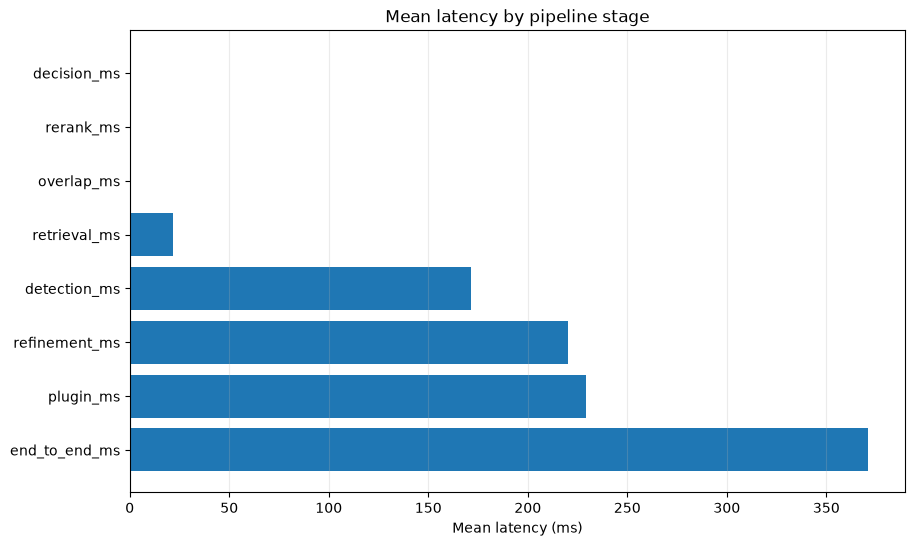

,Stage,Mean (ms),Share of listed stage latency
3,end_to_end_ms,370.8380,0.3659
6,plugin_ms,229.1005,0.2261
2,refinement_ms,220.0000,0.2171
0,detection_ms,171.3277,0.1691
4,retrieval_ms,21.5024,0.0212
1,overlap_ms,0.3000,0.0003
7,rerank_ms,0.2980,0.0003
5,decision_ms,0.0200,0.0000


In [82]:
lat = report["latency"]
lat_rows = []
for stage, vals in lat.items():
    lat_rows.append({
        "Stage": stage,
        "Mean (ms)": vals["mean"],
        "Min (ms)": vals["min"],
        "Max (ms)": vals["max"]
    })
lat_df = pd.DataFrame(lat_rows).sort_values("Mean (ms)", ascending=False)
display(lat_df)

plt.figure(figsize=(10,6))
plt.barh(lat_df["Stage"], lat_df["Mean (ms)"])
plt.xlabel("Mean latency (ms)")
plt.title("Mean latency by pipeline stage")
plt.grid(axis="x", alpha=.25)
plt.show()

lat_df["Share of listed stage latency"] = lat_df["Mean (ms)"] / lat_df["Mean (ms)"].sum()
display(lat_df[["Stage","Mean (ms)","Share of listed stage latency"]])


## 12. Phân tích records chi tiết

`records(1).csv` được dùng để kiểm tra ở mức từng detection/crop: confidence, IoU trước/sau refinement, kết quả retrieval, plugin được chạy, final product, final confidence, latency và trạng thái đúng/sai. Các trường này cũng xuất hiện trong `report.json`. Ví dụ, một record có GT product 4, detection confidence 0.9683, IoU 0.9795 và retrieval rank 1; trong khi các record khác thể hiện rõ trường hợp plugin/fusion sửa kết quả. fileciteturn0file0L719-L748


Kích thước records: (270, 28)


,image_key,source_path,detection_index,crop_id,gt_product_id,gt_matched,detection_confidence,detection_iou_gt,overlap_flagged,refinement_triggered,refinement_used_fallback,iou_before_refine,iou_after_refine,retrieval_top1_product_id,retrieval_top1_similarity,retrieval_gt_rank,decision_status_before,decision_trigger_reasons,plugins_executed,final_product_id,final_status,final_confidence,changed_by_plugin,detection_latency_ms,retrieval_latency_ms,plugin_latency_ms,rerank_latency_ms,correct
0,demo_001_jpg.rf.synthetic0001,data\benchmark\images\demo_001_jpg.rf.syntheti...,0,crop_demo_000000,7,True,0.9662,0.9393,False,False,NaN,NaN,NaN,7,0.9474,1,accepted,NaN,"ocr,barcode",7,accepted,0.9764,False,195.8440,19.3700,153.1080,0.2460,True
1,demo_001_jpg.rf.synthetic0001,data\benchmark\images\demo_001_jpg.rf.syntheti...,1,crop_demo_000000,1,True,0.9855,0.8257,False,False,NaN,NaN,NaN,1,0.9392,1,accepted,NaN,"ocr,color",1,accepted,0.9220,False,195.8440,32.3620,156.0940,0.2950,True
2,demo_001_jpg.rf.synthetic0001,data\benchmark\images\demo_001_jpg.rf.syntheti...,2,crop_demo_000000,8,True,0.9616,0.9411,False,False,NaN,NaN,NaN,8,0.9259,1,accepted,NaN,"ocr,color,barcode",8,accepted,0.9372,False,195.8440,18.3650,231.8970,0.3140,True
3,demo_001_jpg.rf.synthetic0001,data\benchmark\images\demo_001_jpg.rf.syntheti...,3,crop_demo_000000,8,True,0.9629,0.9307,False,False,NaN,NaN,NaN,8,0.9152,1,accepted,NaN,"ocr,color,barcode",8,accepted,0.9232,False,195.8440,20.4570,248.0310,0.3290,True
4,demo_001_jpg.rf.synthetic0001,data\benchmark\images\demo_001_jpg.rf.syntheti...,4,crop_demo_000000,8,True,0.9911,0.8683,True,True,False,0.8683,0.9460,8,0.9081,1,accepted,force,"ocr,color,barcode",8,accepted,0.9990,False,195.8440,30.6800,267.7980,0.3070,True


,count,mean,std,min,25%,50%,75%,max
detection_confidence,270.0000,0.9552,0.0207,0.9020,0.9408,0.9549,0.9709,0.9990
detection_iou_gt,270.0000,0.9281,0.0298,0.8119,0.9092,0.9279,0.9481,0.9900
iou_before_refine,28.0000,0.9251,0.0285,0.8678,0.9068,0.9250,0.9489,0.9793
iou_after_refine,28.0000,0.9650,0.0306,0.8532,0.9502,0.9711,0.9921,0.9950
retrieval_top1_similarity,270.0000,0.9105,0.0624,0.6582,0.8956,0.9238,0.9512,0.9990
retrieval_gt_rank,270.0000,1.1704,0.5594,1.0000,1.0000,1.0000,1.0000,6.0000
final_confidence,270.0000,0.9345,0.0444,0.6550,0.9138,0.9360,0.9626,0.9990
detection_latency_ms,270.0000,171.3277,36.7059,90.0000,153.3230,175.7360,200.3670,231.4240
retrieval_latency_ms,270.0000,21.5024,5.6561,10.0000,17.7070,21.5480,25.3248,43.2340
plugin_latency_ms,270.0000,228.2520,61.9224,0.0000,192.7708,236.6260,272.7665,364.8500


,correct,count
0,True,267
1,False,3


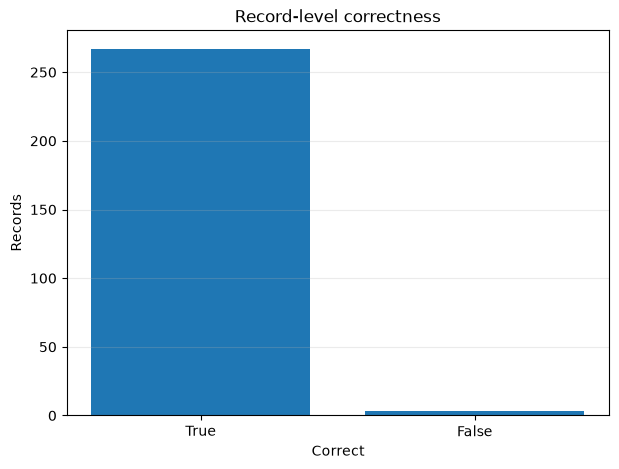

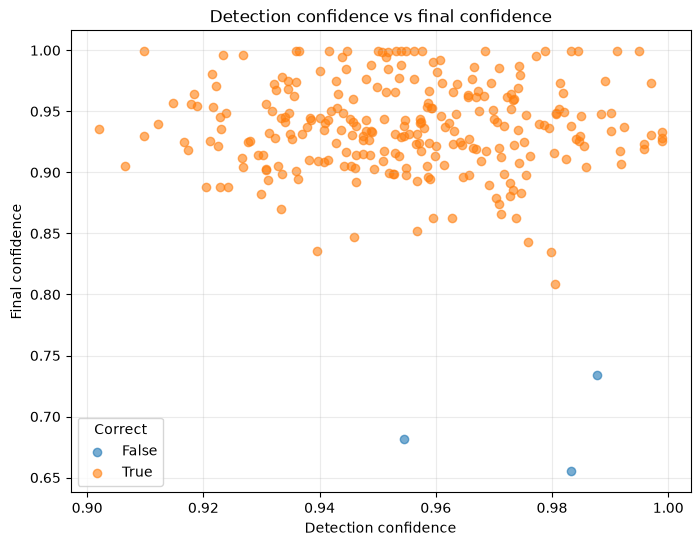

In [83]:
print("Kích thước records:", records.shape)
display(records.head())

num_cols = [c for c in [
    "detection_confidence","detection_iou_gt","iou_before_refine","iou_after_refine",
    "retrieval_top1_similarity","retrieval_gt_rank","final_confidence",
    "detection_latency_ms","retrieval_latency_ms","plugin_latency_ms","rerank_latency_ms"
] if c in records.columns]

display(records[num_cols].describe().T)

if "correct" in records.columns:
    correctness = records["correct"].value_counts(dropna=False).rename_axis("correct").reset_index(name="count")
    display(correctness)
    plt.figure(figsize=(7,5))
    plt.bar(correctness["correct"].astype(str), correctness["count"])
    plt.xlabel("Correct")
    plt.ylabel("Records")
    plt.title("Record-level correctness")
    plt.grid(axis="y", alpha=.25)
    plt.show()

if {"detection_confidence","correct"}.issubset(records.columns):
    plt.figure(figsize=(8,6))
    for label, g in records.groupby("correct"):
        plt.scatter(g["detection_confidence"], g["final_confidence"], label=str(label), alpha=.6)
    plt.xlabel("Detection confidence")
    plt.ylabel("Final confidence")
    plt.title("Detection confidence vs final confidence")
    plt.legend(title="Correct")
    plt.grid(alpha=.25)
    plt.show()


## 13. Tổng hợp lỗi và các điểm cần cải thiện

### Phát hiện chính

1. **Detection tốt:** F1 95.03%, mean IoU 90.70%, chỉ 6 FN trên 293 GT objects. fileciteturn1file5L471-L485
2. **Retrieval là nút thắt:** Top-1 chỉ 54.70%, dù Top-5 đạt 97.56%. Điều này cho thấy đúng sản phẩm thường nằm trong candidate list nhưng chưa được xếp hạng đầu tiên. fileciteturn1file9L789-L805
3. **Fusion có tác động lớn:** accuracy tăng từ 52.03% lên 82.66%, tăng 30.63 điểm phần trăm. fileciteturn1file1L100-L109
4. **Barcode plugin rất yếu:** success rate 3.89%, 247 failures; trong khi Color đạt 100% success và OCR đạt 98.13%. fileciteturn1file9L827-L847
5. **End-to-End còn khoảng cách so với Detection:** F1 giảm xuống 80.47%, với 68 FP và 50 FN. fileciteturn1file1L111-L168
6. **Latency cao:** mean end-to-end gần 49 giây; plugin trung bình khoảng 4.88 giây và refinement khoảng 1.87 giây. fileciteturn0file0L677-L715

### Ưu tiên cải thiện

- Ưu tiên **re-ranking / retrieval Top-1**, đặc biệt cho các product có Top-1 accuracy thấp.
- Giảm false positive ở các product có FP cao.
- Xem lại chiến lược trigger/refinement vì segmentation có cả cải thiện lẫn degradation.
- Điều tra nguyên nhân barcode failure trước khi tăng trọng số barcode trong fusion.
- Tối ưu plugin execution và các case phải chạy nhiều plugin.
- Đánh giá threshold/decision policy để giảm số accepted-but-incorrect.


## 14. Kết luận

Pipeline hiện có **khả năng phát hiện vật thể rất tốt**, nhưng hiệu năng cuối cùng bị giới hạn bởi **nhận dạng sản phẩm, quyết định và các lỗi downstream**. Detection F1 đạt 0.9503 trong khi End-to-End F1 chỉ 0.8047. fileciteturn1file5L467-L475

Đáng chú ý nhất là **Fusion giúp cải thiện accuracy mạnh**, cho thấy việc kết hợp retrieval với các tín hiệu bổ sung là hướng hiệu quả. Tuy nhiên, để nâng End-to-End ổn định hơn, cần tập trung vào Top-1 retrieval, giảm FP/FN theo product và tối ưu latency của plugin/refinement. fileciteturn1file1L100-L109
